# FormFix AI Analytics Notebook

This notebook trains the BiLSTM model, saves graphs for documentation, and generates the confusion matrix and classification metrics.

In [1]:
import json
from pathlib import Path
import os
import sys
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-formfix')
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if (PROJECT_ROOT / 'training').exists():
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))

print('Python executable:', sys.executable)
if 'AI-Trainer/ai-trainer/bin/python' not in sys.executable:
    raise RuntimeError('Jupyter is using the wrong kernel. Select the ai-trainer kernel before running this notebook.')

from training.analytics_helpers import train_bilstm_with_history, evaluate_model

DATASET_PATH = PROJECT_ROOT / 'dataset' / 'processed' / 'exercise_sequences.npz'
MODEL_PATH = PROJECT_ROOT / 'models' / 'exercise_bilstm.keras'
ANALYTICS_DIR = PROJECT_ROOT / 'reports' / 'analytics'
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Dataset path:', DATASET_PATH)
print('Analytics dir:', ANALYTICS_DIR)


Python executable: /Users/syedahmed/AI-Trainer/ai-trainer/bin/python
Project root: /Users/syedahmed/AI-Trainer
Dataset path: /Users/syedahmed/AI-Trainer/dataset/processed/exercise_sequences.npz
Analytics dir: /Users/syedahmed/AI-Trainer/reports/analytics


In [2]:
# Run this cell to train and automatically generate all analytics plots.
history, metrics, labels = train_bilstm_with_history(
    dataset_path=str(DATASET_PATH),
    epochs=30,
    batch_size=32,
    model_path=str(MODEL_PATH),
    analytics_dir=str(ANALYTICS_DIR),
)

print('Top-1 Accuracy:', metrics['top1_accuracy'])
print('Top-3 Accuracy:', metrics['top3_accuracy'])

2026-04-12 16:48:14.694867: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-12 16:48:14.694948: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-12 16:48:14.694958: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-12 16:48:14.695379: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-12 16:48:14.695929: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2026-04-12 16:48:19.702054: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


28/28 [==============================] - 8s 97ms/step - loss: 1.3874 - accuracy: 0.4709 - val_loss: 0.8982 - val_accuracy: 0.6592 - lr: 0.0010
Epoch 2/30
28/28 [==============================] - 1s 44ms/step - loss: 0.9639 - accuracy: 0.7052 - val_loss: 0.7574 - val_accuracy: 0.7623 - lr: 0.0010
Epoch 3/30
28/28 [==============================] - 1s 40ms/step - loss: 0.7866 - accuracy: 0.7377 - val_loss: 0.6855 - val_accuracy: 0.7937 - lr: 0.0010
Epoch 4/30
28/28 [==============================] - 1s 40ms/step - loss: 0.6690 - accuracy: 0.7960 - val_loss: 0.5864 - val_accuracy: 0.8296 - lr: 0.0010
Epoch 5/30
28/28 [==============================] - 1s 39ms/step - loss: 0.5865 - accuracy: 0.8251 - val_loss: 0.6390 - val_accuracy: 0.7758 - lr: 0.0010
Epoch 6/30
28/28 [==============================] - 1s 39ms/step - loss: 0.5844 - accuracy: 0.7982 - val_loss: 0.5697 - val_accuracy: 0.7982 - lr: 0.0010
Epoch 7/30
28/28 [==============================] - 1s 39ms/step - loss: 0.5313 - accur

In [3]:
# If you already trained the model, run this instead of retraining.
metrics = evaluate_model(
    model_path=str(MODEL_PATH),
    dataset_path=str(DATASET_PATH),
    analytics_dir=str(ANALYTICS_DIR),
)
print(json.dumps({
    'top1_accuracy': metrics['top1_accuracy'],
    'top3_accuracy': metrics['top3_accuracy']
}, indent=2))

{
  "top1_accuracy": 93.72,
  "top3_accuracy": 99.82
}


accuracy_vs_epoch.png


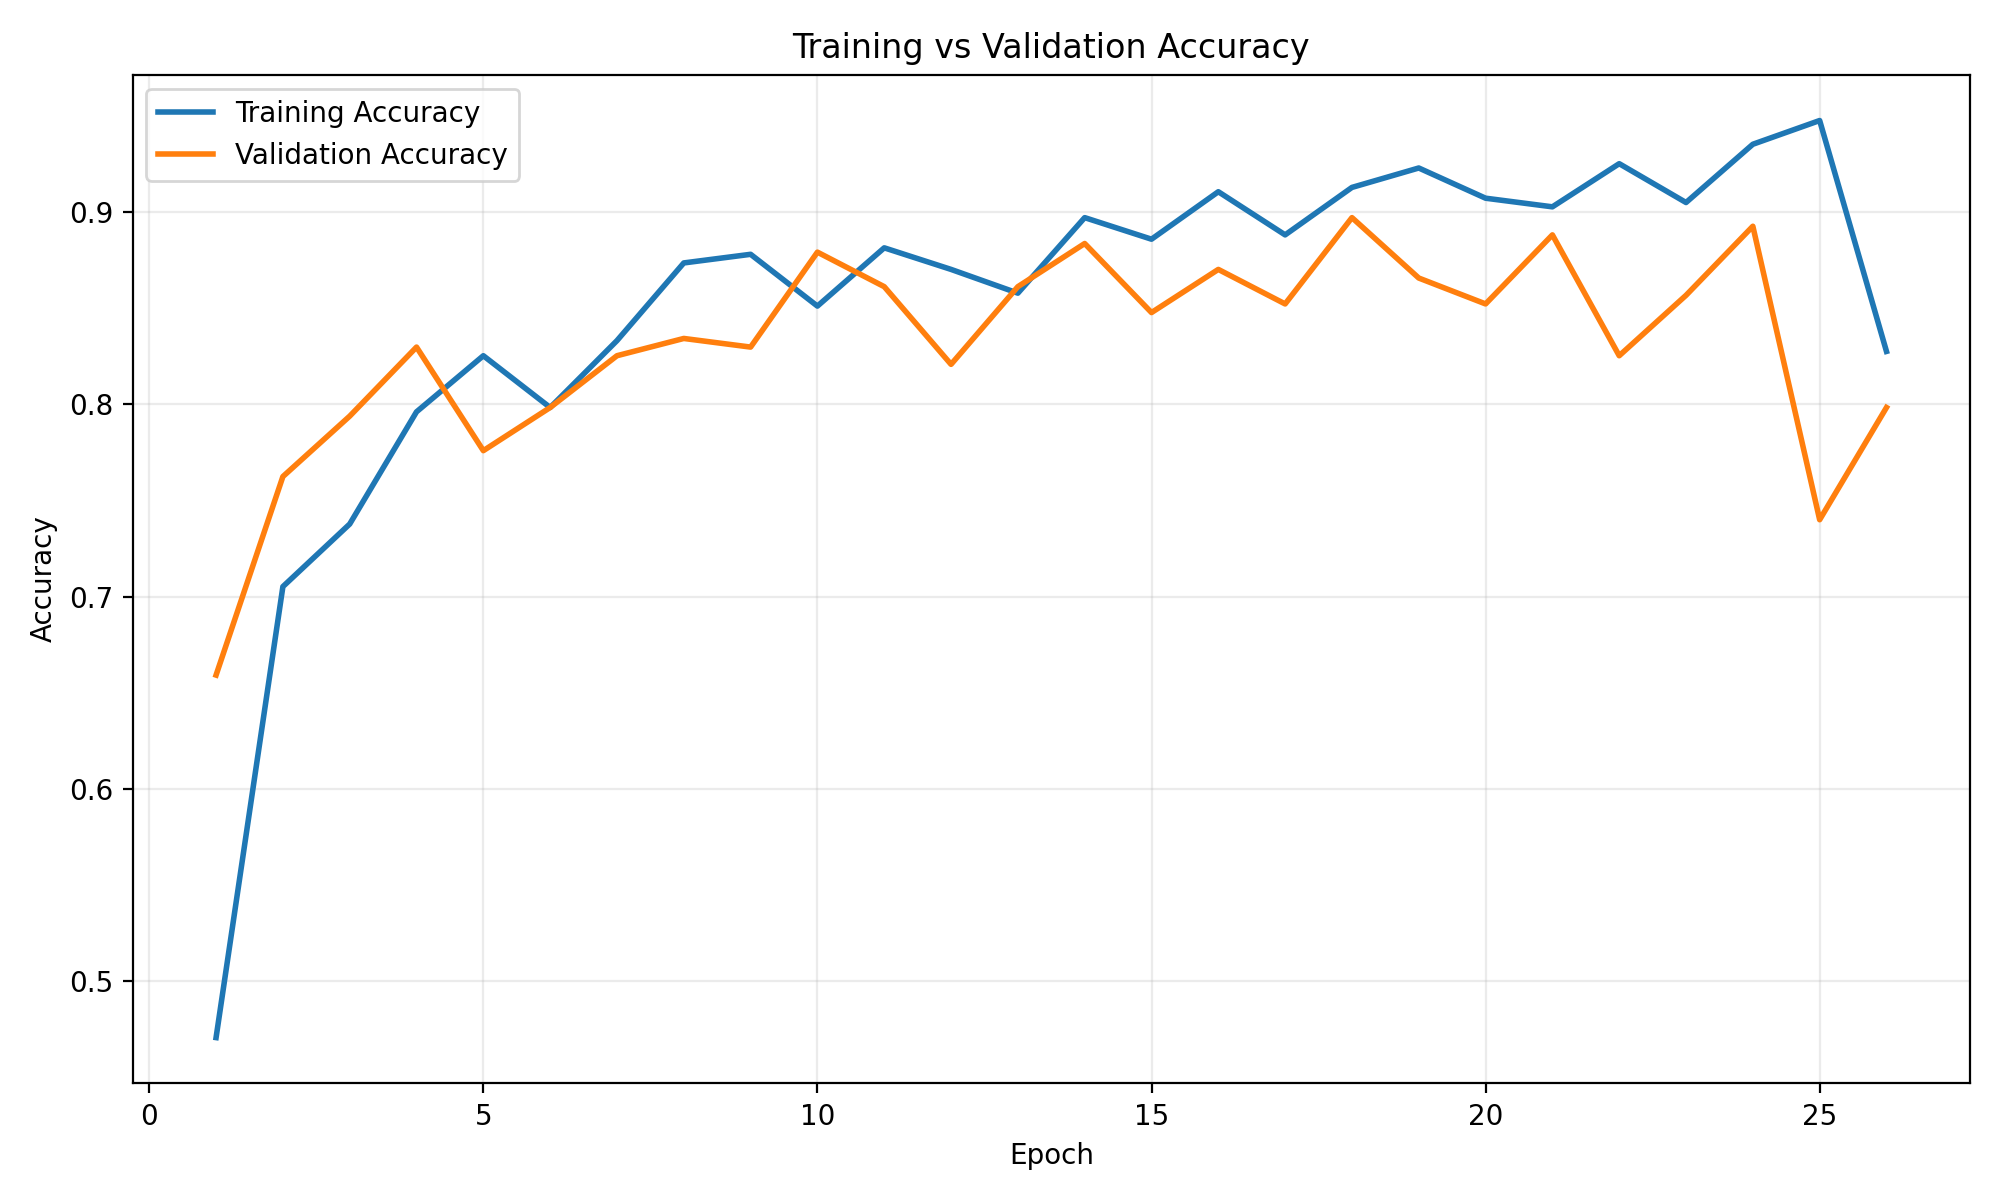

loss_vs_epoch.png


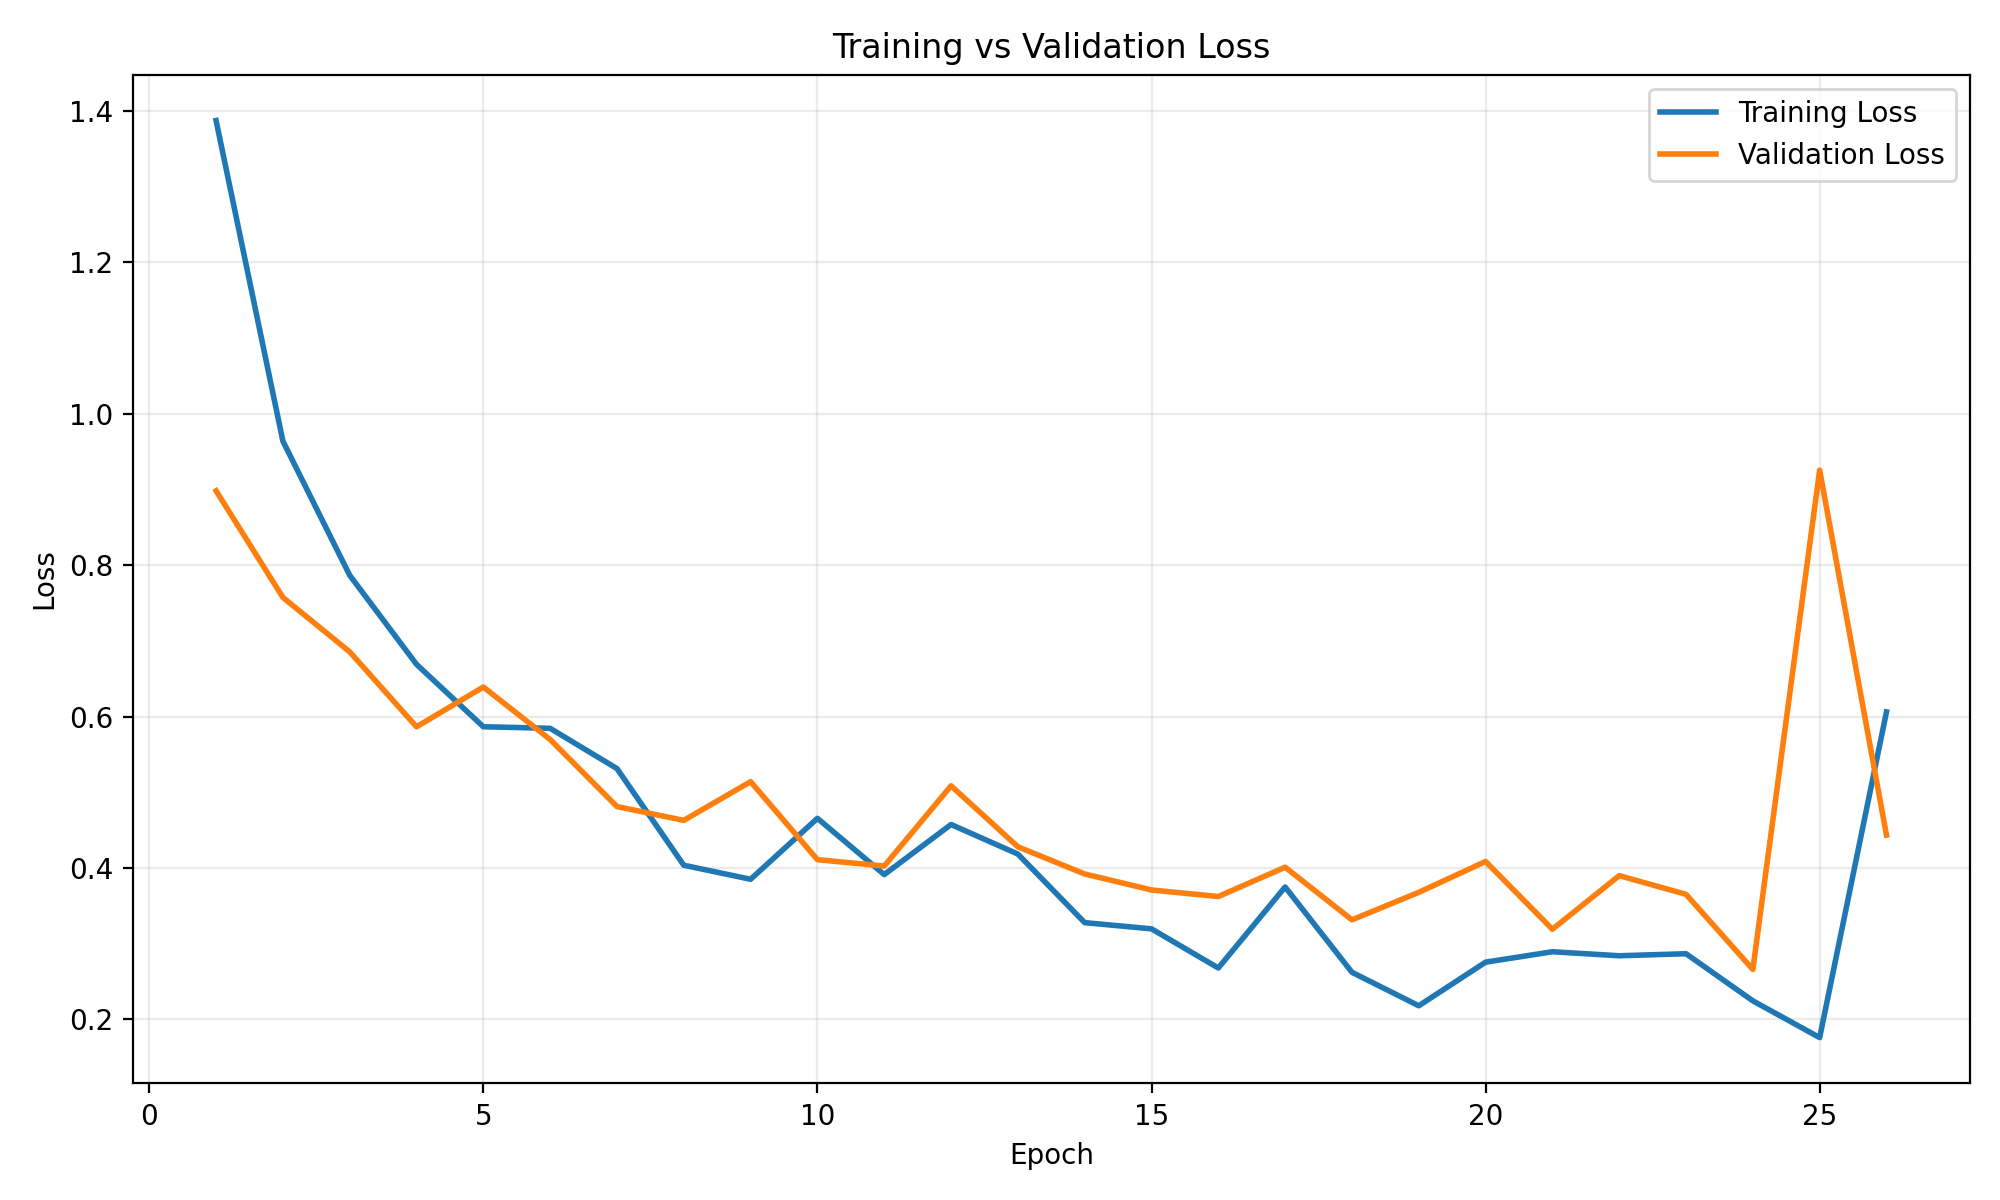

confusion_matrix.png


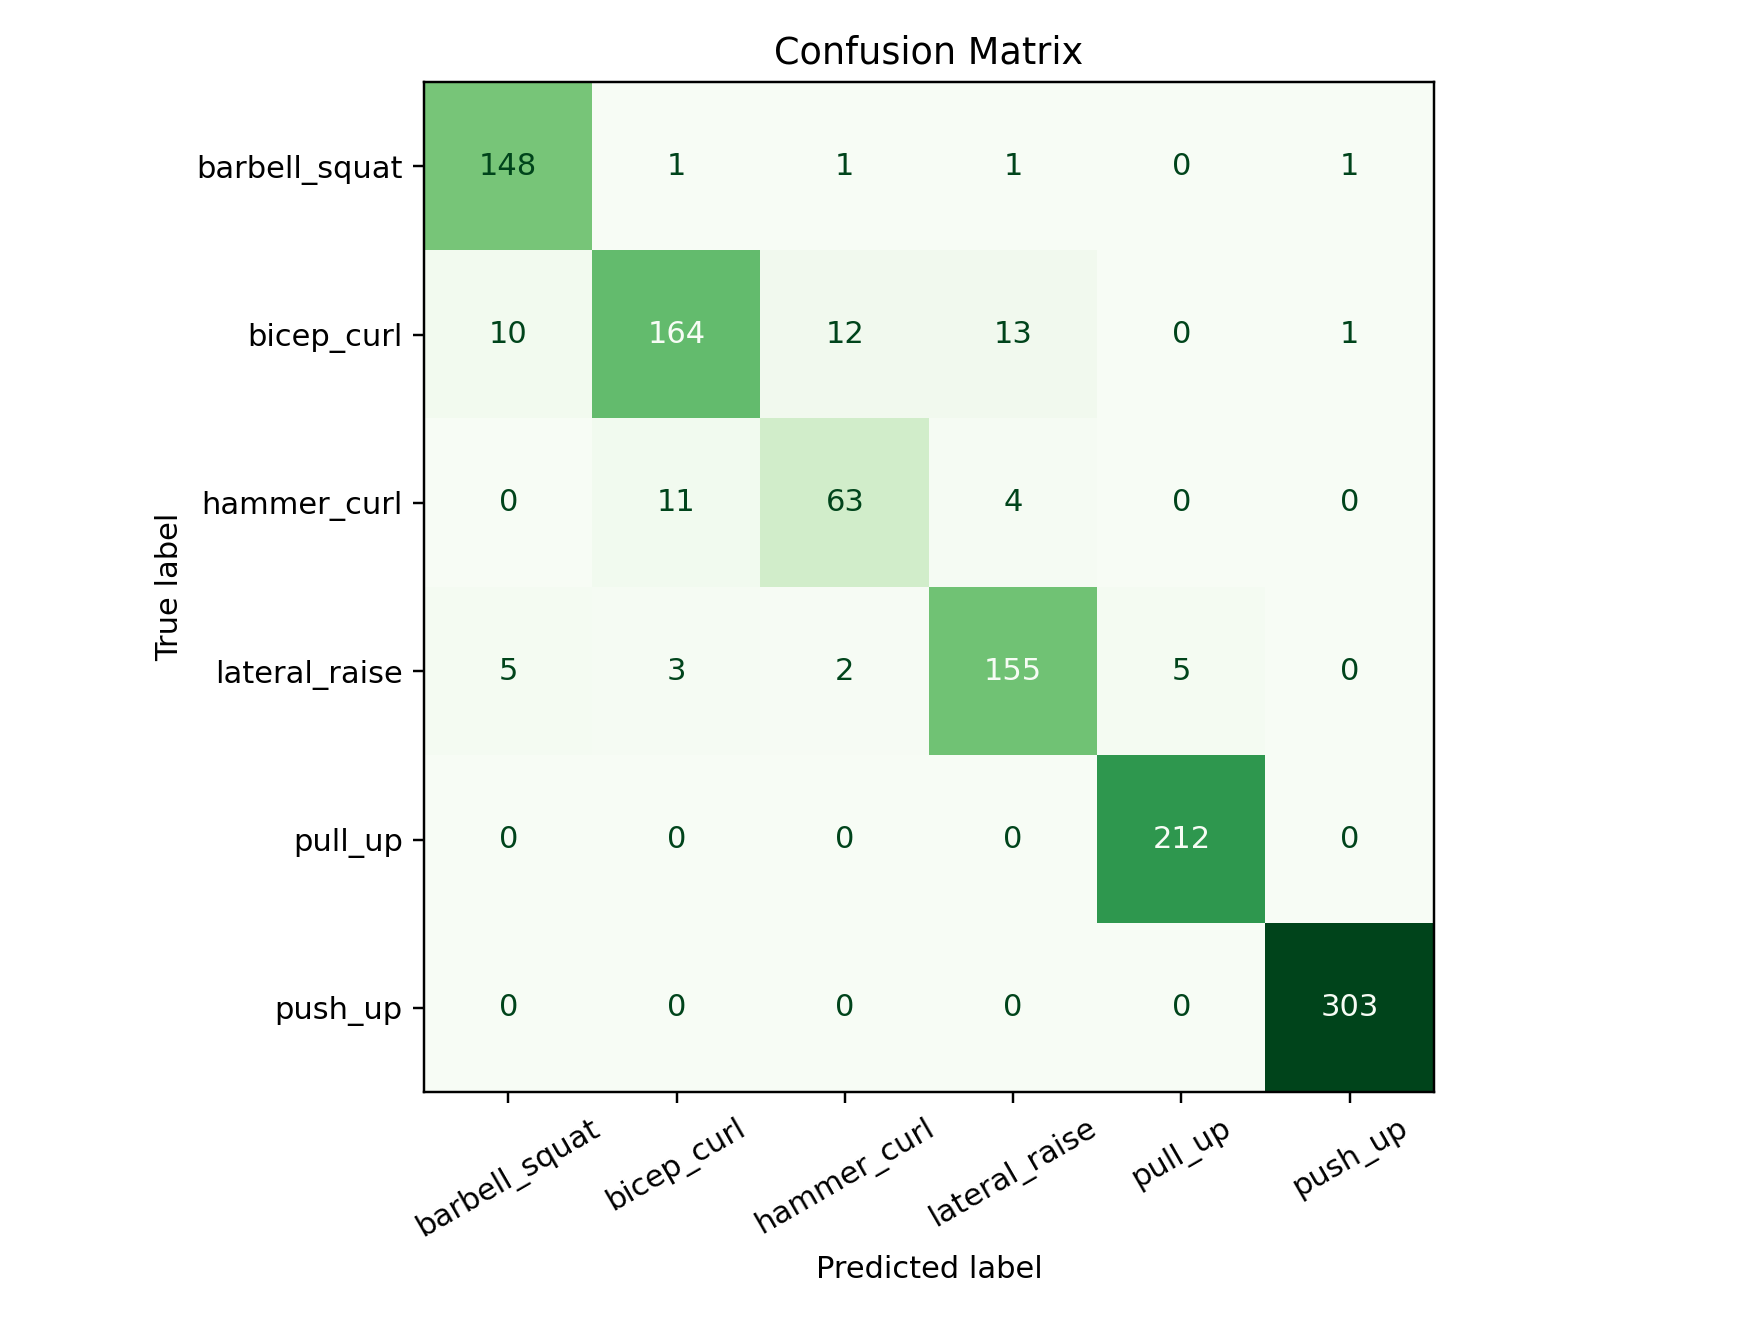

In [4]:
# Display graphs for documentation
for file_name in ['accuracy_vs_epoch.png', 'loss_vs_epoch.png', 'confusion_matrix.png']:
    file_path = ANALYTICS_DIR / file_name
    print(file_name)
    display(Image(filename=str(file_path)))

In [5]:
# Display saved metrics summary
summary = json.loads((ANALYTICS_DIR / 'metrics_summary.json').read_text())
summary

{'top1_accuracy': 93.72,
 'top3_accuracy': 99.82,
 'classification_report': {'barbell_squat': {'precision': 0.9079754601226994,
   'recall': 0.9736842105263158,
   'f1-score': 0.9396825396825397,
   'support': 152.0},
  'bicep_curl': {'precision': 0.9162011173184358,
   'recall': 0.82,
   'f1-score': 0.8654353562005277,
   'support': 200.0},
  'hammer_curl': {'precision': 0.8076923076923077,
   'recall': 0.8076923076923077,
   'f1-score': 0.8076923076923077,
   'support': 78.0},
  'lateral_raise': {'precision': 0.8959537572254336,
   'recall': 0.9117647058823529,
   'f1-score': 0.9037900874635568,
   'support': 170.0},
  'pull_up': {'precision': 0.9769585253456221,
   'recall': 1.0,
   'f1-score': 0.9883449883449883,
   'support': 212.0},
  'push_up': {'precision': 0.9934426229508196,
   'recall': 1.0,
   'f1-score': 0.9967105263157895,
   'support': 303.0},
  'accuracy': 0.9372197309417041,
  'macro avg': {'precision': 0.9163706317758864,
   'recall': 0.9188568706834962,
   'f1-score'